# Work flow
----------------------------------------------------------------------
## 1. Generate spike trains
## 2. Generate calcium dynamic from spike trains with multiple noise level
## 3. Perform spike deconvolution and compare the result with original spike trains
----------------------------------------------------------------------

# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from oasis.functions import gen_data, gen_sinusoidal_data, deconvolve, estimate_parameters
from oasis.plotting import simpleaxis
from oasis.oasis_methods import oasisAR1, oasisAR2
from suite2p.extraction import dcnv
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import find_peaks
import os
import glob
import h5py
import warnings
warnings.simplefilter('ignore')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
from oasis.functions import gen_data, gen_sinusoidal_data, deconvolve, estimate_parameters
from oasis.plotting import simpleaxis
from oasis.oasis_methods import oasisAR1, oasisAR2

# Simulation

In [3]:
def generate_spikes(rate, duration, sf_ephys):
    """
    Generate spikes based on a Poisson process.
    
    Parameters:
    - rate: average rate of spikes per second.
    - duration: duration of the spike train in seconds.
    - sf_ephys: sampling frequency of spiking activity
    
    Returns:
    - spike_times: array of spike times.
    """
    np.random.seed(0)
    mean_interval = 1.0 / rate
    times = np.random.exponential(scale=mean_interval, size=int(rate * duration * 1.5))
    spike_times = np.cumsum(times)
    spike_times = spike_times[spike_times < duration]
    spike_times = (spike_times*sf_ephys).astype('int')
    t_ephys=np.arange(0, duration, 1/sf_ephys)
    return t_ephys,spike_times

In [9]:
def simulate_calcium_dynamics(spike_train, duration, sf_ephys=1000, sf_imaging=15.2, tau_rise=0.2, tau_decay=1.0, A=1, Ca_rest=1000, sigma=0.1, eta=0.01):
    """
    Simulate calcium dynamics with noise based on spike times.
    
    Parameters:
    - spike_train: array of binary spikes (N x Time).
    - duration: duration of the simulation in seconds.
    - sf_imaging: sampling frequency of calcium signal.
    - tau_rise: rise time constant of the calcium signal.
    - tau_decay: decay time constant of the calcium signal.
    - A: amplitude of calcium increase per spike.
    - Ca_rest: resting calcium concentration.
    - sigma: standard deviation of the measurement noise.
    - eta: scale of the evolution noise.
    
    Returns:
    - t: array of time points.
    - Ca: array of noisy calcium concentrations over time.
    """
    
    dt = 1 / sf_imaging
    t_imaging = np.arange(0, duration, dt)
    
    # Simulate the spikes and calcium concentration
    N_neuron=spike_train.shape[0]
    Ca_traces=[]
    for i in range(N_neuron):
        spike_times=np.where(spike_train[i]==1)[0]/sf_ephys
        Ca = np.zeros_like(t_imaging) + Ca_rest
        for spike_time in spike_times:
            spike_idx = int(spike_time / dt)
            t_since_spike = t_imaging[spike_idx:] - t_imaging[spike_idx]
            Ca[spike_idx:] += A *Ca_rest* (np.exp(-t_since_spike / tau_decay) - np.exp(-t_since_spike / tau_rise))
        Ca[Ca<0]=0
        # Add measurement noise
        measurement_noise = np.random.normal(0, sigma * Ca_rest, size=len(t_imaging))
        Ca = Ca + measurement_noise
        Ca_traces.append(Ca)
    
    # Add evolution noise using Brownian motion
    np.random.seed(0)
    B = np.zeros_like(t_imaging)  # Drifting baseline B(t)
    dW = np.random.normal(0, np.sqrt(dt) * eta * Ca_rest, size=len(t_imaging))
    B += np.cumsum(dW)  # Integrate the Brownian motion over time
    B = np.tile(B, (N_neuron,1))
    # Combine the calcium signal with noise
    Ca_traces = Ca_traces + B
    return t_imaging, Ca_traces


In [5]:
def calc_dF_F(F, sf_imaging, win_baseline=60):
    from scipy.ndimage import percentile_filter
    #calculate baseline
    Fbase = percentile_filter(F, percentile=8, size=int(win_baseline*sf_imaging), axes=1)
    #calculate dF/F
    Fcorr = F-Fbase
    dF_F = Fcorr/Fbase
    return Fcorr, dF_F

In [13]:
# Parameters for spike train generation
np.random.seed(0)
N_Neuron = 100 # Number of neurons
rate=np.random.uniform(.005, .05, N_Neuron) # Firing rate distribution
duration=500 #simulation duration in seconds
sf_ephys=1000 #sampling frequency of spiking

# Generate spike trains for N_Neurons
Spike_train = np.zeros([N_Neuron,int(duration*sf_ephys)])
for i in range(N_Neuron):
    t_ephys, spike_times=generate_spikes(rate=rate[i], duration=duration, sf_ephys=sf_ephys)
    Spike_train[i,spike_times]=1

# Generate calcium dynamics based on spike trains with different sigmas
sf_imaging=30
sigmas = [0,0.1,0.2] # shot noise level
Ca_dynamics_all = {}
pure_Ca_dynamics_all = {}
for v in sigmas:
    t_imaging, Ca_dynamics = simulate_calcium_dynamics(Spike_train, duration=duration, sf_ephys=sf_ephys, sf_imaging=sf_imaging, tau_rise=0.002,
                                                          tau_decay=5, A=0.76, Ca_rest=10, sigma=v, eta=0.005)
    Ca_dynamics_all.update({v:Ca_dynamics})
    pure_Ca_dynamics_all.update({v:pure_Ca_dynamics})

In [14]:
Fcorr_sim_all={} # baseline corrected F value
dF_F_sim_all={} # baseline corrected dF/F0 value
for i in Ca_dynamics_all.keys():
    Fcorr_sim, dF_F_sim=calc_dF_F(Ca_dynamics_all[i], sf_imaging, win_baseline=60)
    Fcorr_sim_all.update({i:Fcorr_sim})
    dF_F_sim_all.update({i:dF_F_sim})

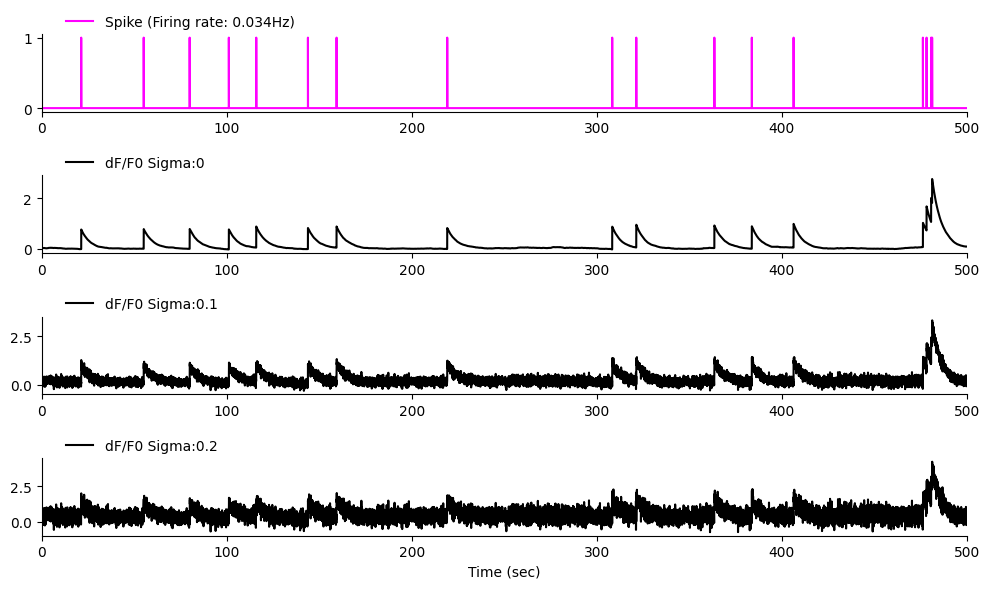

In [15]:
# Plot example neuron
Cell_id=1
plt.figure(figsize=(10,6), tight_layout=True)
plt.subplot(len(dF_F_sim_all.keys())+1,1,1)
plt.plot(t_ephys,Spike_train[Cell_id], color='magenta', label='Spike (Firing rate: '+str(np.sum(Spike_train[Cell_id])/duration)+'Hz)')
plt.xlim(0,duration)
plt.legend(ncol=3, frameon=False, loc=(.02,1));
for i,k in enumerate(dF_F_sim_all.keys()):
    plt.subplot(len(dF_F_sim_all.keys())+1,1,i+2)
    plt.plot(t_imaging,dF_F_sim_all[k][Cell_id], color='black', label='dF/F0 Sigma:'+str(k))
    plt.legend(ncol=3, frameon=False, loc=(.02,1));
    plt.xlim(0,duration)
plt.xlabel('Time (sec)')
sns.despine()

plt.subplots_adjust(wspace=0.4, hspace=0.6)

# Comparison between actual recoding and simulation

## Standarized shot noise level

In [17]:
standarized_noise_level_all={}
for i in dF_F_sim_all.keys():
    standarized_noise_level = np.median(abs(np.diff(dF_F_sim_all[i],axis=1)*100)/np.sqrt(sf_imaging),axis=1)
    standarized_noise_level_all.update({i:standarized_noise_level})

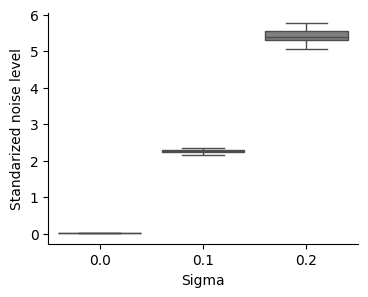

In [19]:
data = {'Key': [],'Value': []}
for key, values in standarized_noise_level_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)
df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df, color='gray')
plt.xlabel('Sigma')
plt.ylabel('Standarized noise level')
# plt.yscale('log')
sns.despine()

# Compare spike inference result

## Baseline correction -> deconvolution

In [22]:
def baseline_corr(F, fs, baseline='maximin', sig_baseline = 10, win_baseline=60, prctile_baseline=15):
    '''
    From suite2p
    sig_baseline:in bins, standard deviation of gaussian with which to smooth
    win_baseline:in seconds, window in which to compute max/min filters
    '''
    from scipy.ndimage import maximum_filter1d, minimum_filter1d, gaussian_filter, percentile_filter
    win = int(win_baseline * fs)
    if baseline == "maximin":
        Flow = gaussian_filter(F, [0., sig_baseline])
        Flow = minimum_filter1d(Flow, win)
        Flow = maximum_filter1d(Flow, win)
    elif baseline == "constant":
        Flow = gaussian_filter(F, [0., sig_baseline])
        Flow = np.amin(Flow)
    elif baseline == "constant_prctile":
        Flow = np.percentile(F, prctile_baseline, axis=1)
        Flow = np.expand_dims(Flow, axis=1)
    elif baseline == "percentile":
        Flow = percentile_filter(F, percentile=prctile_baseline, size=win, axes=1)
    elif baseline == "constant_median":
        Flow = np.median(F, axis=1)
        Flow = np.expand_dims(Flow, axis=1)
    Fcorr = F - Flow
    
    return Fcorr

In [20]:
def plot_trace(t_imaging, t_ephys, dF_F, denoised, inf_spikes,true_spikes, threshold=0.2, xwindow=[0, 1000]):
    plt.figure(figsize=(10,3), tight_layout=True)
    plt.subplot(211)
    plt.plot(t_imaging, denoised, lw=1, label='denoised')
    plt.plot(t_imaging, dF_F, label='data', zorder=-12, c='y')
    plt.legend(ncol=3, frameon=False, loc=(.02,.9))
    plt.xlim(xwindow[0], xwindow[1])
    # plt.ylim(-0.5,5)
    simpleaxis(plt.gca())
    
    plt.subplot(212)
    spikes, _ = find_peaks(inf_spikes, height=threshold)
    num_inf_spikes = len(spikes)
    plt.plot(t_ephys, true_spikes+1.5, lw=1, label='true spike:'+str(len(np.where(true_spikes>0)[0])), c='black')
    plt.plot(t_imaging, inf_spikes, lw=1, label='deconvolved:'+str(num_inf_spikes), c='g')
    plt.hlines(xmin=xwindow[0], xmax=xwindow[1], y=threshold, color='red', lw=0.5, label='threhsold='+str(threshold))
    plt.ylim(0,3)
    plt.legend(ncol=3, frameon=False, loc=(.02,.9));
    simpleaxis(plt.gca())
    plt.xlim(xwindow[0], xwindow[1])
    plt.xlabel('Time (sec)')
 
    plt.subplots_adjust(wspace=0.4, hspace=0.6)

## OASIS AR2 model with regularization

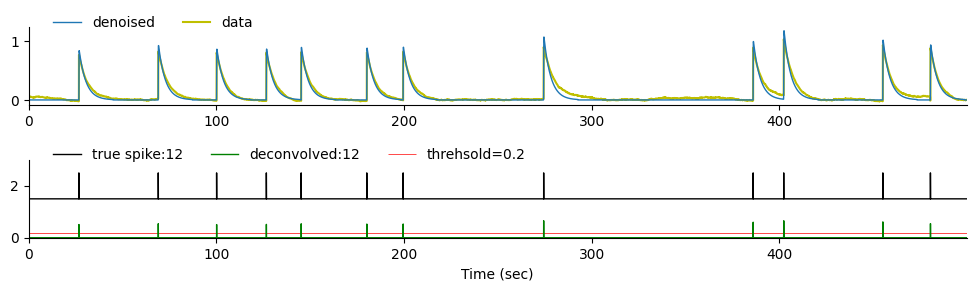

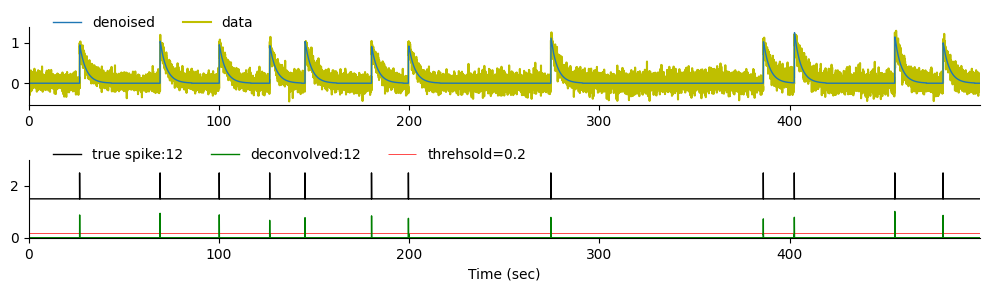

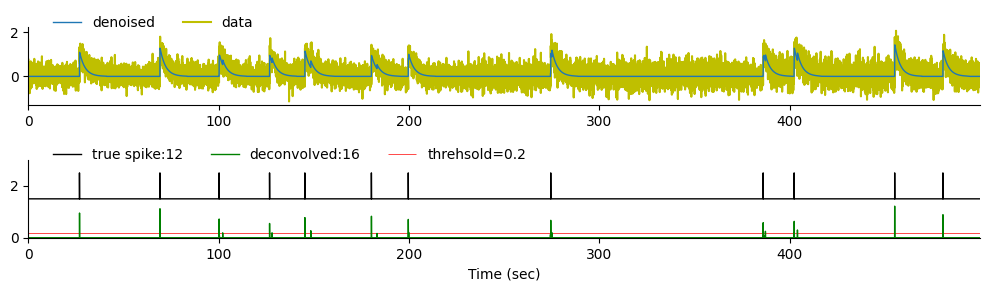

In [74]:
Cell_id=0
threshold=0.2
for k in dF_F_sim_all.keys():
    F_base_corr = baseline_corr(dF_F_sim_all[k], fs=sf_imaging, baseline='maximin', sig_baseline = 60, win_baseline= 60)

    denoised, inf_spikes, b, g, lam = deconvolve(F_base_corr[Cell_id], 
                             g=estimate_parameters(F_base_corr[Cell_id], p=2,fudge_factor=1)[0], 
                             penalty=1)
    plot_trace(t_imaging, t_ephys, F_base_corr[Cell_id], denoised, inf_spikes, Spike_train[Cell_id], 
               threshold=threshold, xwindow=[t_imaging.min(), t_imaging.max()])

CPU times: user 1min 5s, sys: 48.8 s, total: 1min 53s
Wall time: 17.7 s


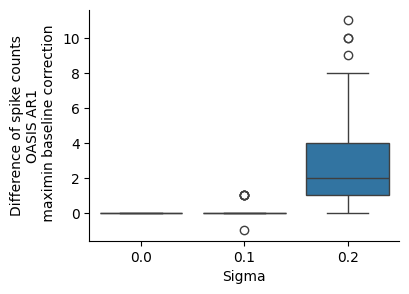

In [73]:
%%time
denoised_all={}
inf_spikes_all={}
for i in dF_F_sim_all.keys():
    denoised = []
    inf_spikes = []
    F_base_corr = baseline_corr(dF_F_sim_all[i], fs=sf_imaging, baseline='maximin', sig_baseline = 60, win_baseline=60)
    for v in range(Fcorr_sim_all[i].shape[0]):
        c, s, b, g, lam = deconvolve(F_base_corr[v], 
                             g=estimate_parameters(F_base_corr[v], p=2,fudge_factor=1)[0], 
                             penalty=1)
        denoised.append(c)
        inf_spikes.append(s)
    denoised=np.array(denoised)
    inf_spikes=np.array(inf_spikes)
    denoised_all.update({i:denoised})
    inf_spikes_all.update({i:inf_spikes})

diff_spk_num_all = {}
inf_spike_train_all = {}
for k in inf_spikes_all.keys() :
    inf_spike_train = np.zeros(inf_spikes_all[k].shape)
    for i in range(inf_spike_train.shape[0]):
        inf_spikes, _ = find_peaks(inf_spikes_all[k][i], height=threshold)
        inf_spike_train[i][inf_spikes]=1
    diff_spk_num = (np.sum(inf_spike_train,axis=1)-np.sum(Spike_train,axis=1))
    diff_spk_num_all.update({k:diff_spk_num})
    inf_spike_train_all.update({k:inf_spike_train})
data = {'Key': [],'Value': []}
for key, values in diff_spk_num_all.items():
    data['Key'].extend([key] * len(values))
    data['Value'].extend(values)

df = pd.DataFrame(data)
# Seabornを使用してViolin plotを作成
plt.figure(figsize=(4, 3), dpi=100)
sns.boxplot(x='Key', y='Value', data=df)
# plt.ylim(-5,50)
plt.xlabel('Sigma')
plt.ylabel('Difference of spike counts\nOASIS AR1\n maximin baseline correction')
sns.despine()

In [54]:
g

0.9930222294286452

## OASIS AR1 model without thresholding

In [46]:
# for k in dF_F_sim_all.keys():
#     F_base_corr = baseline_corr(dF_F_sim_all[k], fs=sf_imaging, baseline='maximin', sig_baseline = 60, win_baseline= 60)

#     denoised, inf_spikes = oasisAR1(F_base_corr[Cell_id], g=estimate_parameters(F_base_corr[Cell_id], p=1)[0])
#     plot_trace(t_imaging, t_ephys, F_base_corr[Cell_id], denoised, inf_spikes, Spike_train[Cell_id], 
#                threshold=threshold, xwindow=[t_imaging.min(), t_imaging.max()])

## OASIS AR1 model with thresholding

In [47]:
# threshold=0.2
# for k in dF_F_sim_all.keys():
#     F_base_corr = baseline_corr(dF_F_sim_all[k], fs=sf_imaging, baseline='maximin', sig_baseline = 60, win_baseline= 60)

#     denoised, inf_spikes = oasisAR1(F_base_corr[Cell_id], g=estimate_parameters(F_base_corr[Cell_id], p=1)[0], s_min=threshold)
#     plot_trace(t_imaging, t_ephys, F_base_corr[Cell_id], denoised, inf_spikes, Spike_train[Cell_id], 
#                threshold=threshold, xwindow=[t_imaging.min(), t_imaging.max()])